In [1]:
import os
import sys

# Get the current directory (Graphs folder)
current_dir = os.getcwd()
# Get the parent directory
parent_dir = os.path.abspath(os.path.join(current_dir, os.pardir))
# Add the parent directory to the sys.path
sys.path.append(parent_dir)
# Now you can import the RQAOA module

from concurrent.futures import ProcessPoolExecutor
from utils import *
from graphs import *
from RQAOA import *
from solvers import *
import warnings
warnings.filterwarnings("ignore")
import matplotlib.pyplot as plt

In [2]:
graph = generate_d_regular_graph(64, 4, seed=42, e_dist=[25, 25])
edges, adj_mat = graph_to_array(graph)
max_freq = get_max_frequency(edges, adj_mat)

opt_cost, mipgap, solution_list = find_ground_state_ising(graph)

Set parameter Username
Academic license - for non-commercial use only - expires 2025-01-14
Gurobi Optimizer version 11.0.0 build v11.0.0rc2 (linux64 - "Fedora Linux 39 (Workstation Edition)")

CPU model: 13th Gen Intel(R) Core(TM) i7-1360P, instruction set [SSE2|AVX|AVX2]
Thread count: 16 physical cores, 16 logical processors, using up to 16 threads

Optimize a model with 0 rows, 64 columns and 0 nonzeros
Model fingerprint: 0x813afde3
Model has 128 quadratic objective terms
Variable types: 0 continuous, 64 integer (64 binary)
Coefficient statistics:
  Matrix range     [0e+00, 0e+00]
  Objective range  [4e+01, 4e+02]
  QObjective range [8e+00, 7e+02]
  Bounds range     [1e+00, 1e+00]
  RHS range        [0e+00, 0e+00]
Found heuristic solution: objective 2994.0000000
Found heuristic solution: objective -2760.000000
Presolve removed 0 rows and 13 columns
Presolve time: 0.04s
Presolved: 109 rows, 160 columns, 327 nonzeros
Variable types: 0 continuous, 160 integer (160 binary)

Root relaxati

In [3]:
2*max_freq + 1

1113.0

In [4]:
# Partial function for QAOA expectation cost
qaoa = partial(QAOA_Expectation_Cost, edges, adj_mat)

# Define the grid of gamma and beta values
gamma_vals1 = np.arange(0, np.pi+np.pi/20, np.pi/20)
gamma_vals2 = np.arange(0, np.pi+np.pi/40, np.pi/40)
gamma_vals3 = np.arange(0, np.pi+np.pi/60, np.pi/60)
gamma_vals4 = np.arange(0, np.pi+1/(2*max_freq + 1), 1/(2*max_freq + 1))
beta_vals = np.arange(0, np.pi/2, np.pi/40)

# Create a meshgrid for gamma and beta
gamma1, beta1 = np.meshgrid(gamma_vals1, beta_vals)
gamma2, beta2 = np.meshgrid(gamma_vals2, beta_vals)
gamma3, beta3 = np.meshgrid(gamma_vals3, beta_vals)
gamma4, beta4 = np.meshgrid(gamma_vals4, beta_vals)


# Flatten the meshgrid to create pairs of (gamma, beta)
params1 = np.column_stack((gamma1.ravel(), beta1.ravel()))
params2 = np.column_stack((gamma2.ravel(), beta2.ravel()))
params3 = np.column_stack((gamma3.ravel(), beta3.ravel()))
params4 = np.column_stack((gamma4.ravel(), beta4.ravel()))

# Compute QAOA costs using parallel processing
with ProcessPoolExecutor(max_workers=15) as executor:
    cost_values1 = np.array(list(executor.map(qaoa, params1))).reshape(gamma1.shape)
with ProcessPoolExecutor(max_workers=15) as executor:
    cost_values2 = np.array(list(executor.map(qaoa, params2))).reshape(gamma2.shape)
with ProcessPoolExecutor(max_workers=15) as executor:
    cost_values3 = np.array(list(executor.map(qaoa, params3))).reshape(gamma3.shape)
with ProcessPoolExecutor(max_workers=15) as executor:
    cost_values4 = np.array(list(executor.map(qaoa, params4))).reshape(gamma4.shape)

In [5]:
# Generate entries from 0 to π with spacing 1/(2*max_freq + 1)
entries_list1 = np.arange(0, np.pi + np.pi/20, np.pi/20)
entries_list2 = np.arange(0, np.pi + np.pi/40, np.pi/40)
entries_list3 = np.arange(0, np.pi + np.pi/60, np.pi/60)
entries_list4 = np.arange(0, np.pi + 1/(2*max_freq + 1), 1/(2*max_freq + 1))
# Partial function for computing cost based on gamma
qaoa_gamma = partial(gamma_cost, edges, adj_mat)

# Compute costs in parallel
with ProcessPoolExecutor() as executor:
    costs1 = list(executor.map(qaoa_gamma, entries_list1))
# Compute costs in parallel
with ProcessPoolExecutor() as executor:
    costs2 = list(executor.map(qaoa_gamma, entries_list2))
# Compute costs in parallel
with ProcessPoolExecutor() as executor:
    costs3 = list(executor.map(qaoa_gamma, entries_list3))
# Compute costs in parallel
with ProcessPoolExecutor() as executor:
    costs4 = list(executor.map(qaoa_gamma, entries_list4))

# Normalize the costs
costs1 = [(cost / opt_cost) for cost in costs1]
costs2 = [(cost / opt_cost) for cost in costs2]
costs3 = [(cost / opt_cost) for cost in costs3]
costs4 = [cost / opt_cost for cost in costs4]

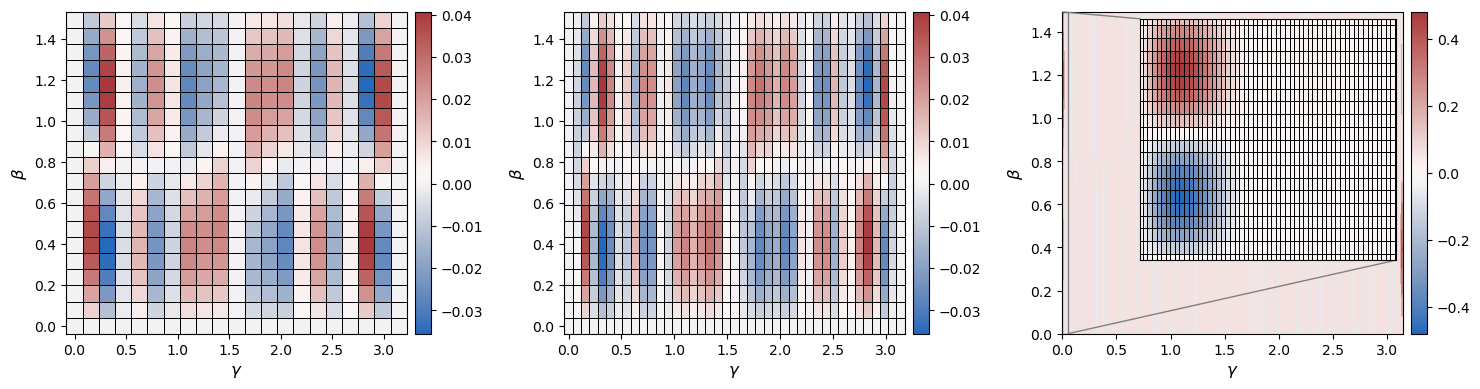

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Use a Seaborn style for clean visuals
#sns.set(style='whitegrid')

# Create a figure with a 1x3 grid of subplots
fig, ax = plt.subplots(1, 3, figsize=(15, 4))

# Define common colormap
cmap = 'vlag'

# First grid plot using pcolormesh
cp1 = ax[0].pcolormesh(gamma1, beta1, cost_values1/opt_cost, cmap=cmap, edgecolors='black', linewidth=0.5)
ax[0].set_xlabel(r'$\gamma$', fontsize=12)
ax[0].set_ylabel(r'$\beta$', fontsize=12)
fig.colorbar(cp1, ax=ax[0], orientation='vertical', pad=0.02)

# Second grid plot using pcolormesh
cp2 = ax[1].pcolormesh(gamma2, beta2, cost_values2/opt_cost, cmap=cmap, edgecolors='black', linewidth=0.5)
ax[1].set_xlabel(r'$\gamma$', fontsize=12)
ax[1].set_ylabel(r'$\beta$', fontsize=12)
fig.colorbar(cp2, ax=ax[1], orientation='vertical', pad=0.02)

# Third grid plot using contourf
cp3 = ax[2].contourf(gamma4, beta4, cost_values4/opt_cost, cmap=cmap)
ax[2].set_xlabel(r'$\gamma$', fontsize=12)
ax[2].set_ylabel(r'$\beta$', fontsize=12)

# Inset plot for the 4th plot within the 3rd plot
axins = inset_axes(ax[2], width="75%", height="75%", loc='upper right')
cp4 = axins.pcolormesh(gamma4, beta4, cost_values4/opt_cost, cmap=cmap, edgecolors='black', linewidth=0.5)
axins.set_xlim([0, 0.05])
axins.set_ylim([0, max(beta3.ravel())])  # Adjust according to the data range
axins.set_xticks([])
axins.set_yticks([])

# Draw lines connecting the inset to the main plot
mark_inset(ax[2], axins, loc1=2, loc2=4, fc="none", ec="0.5")
fig.colorbar(cp4, ax=ax[2], orientation='vertical', pad=0.02)

# Adjust subplot layout for better spacing
plt.tight_layout()

# Display the plots
plt.show()


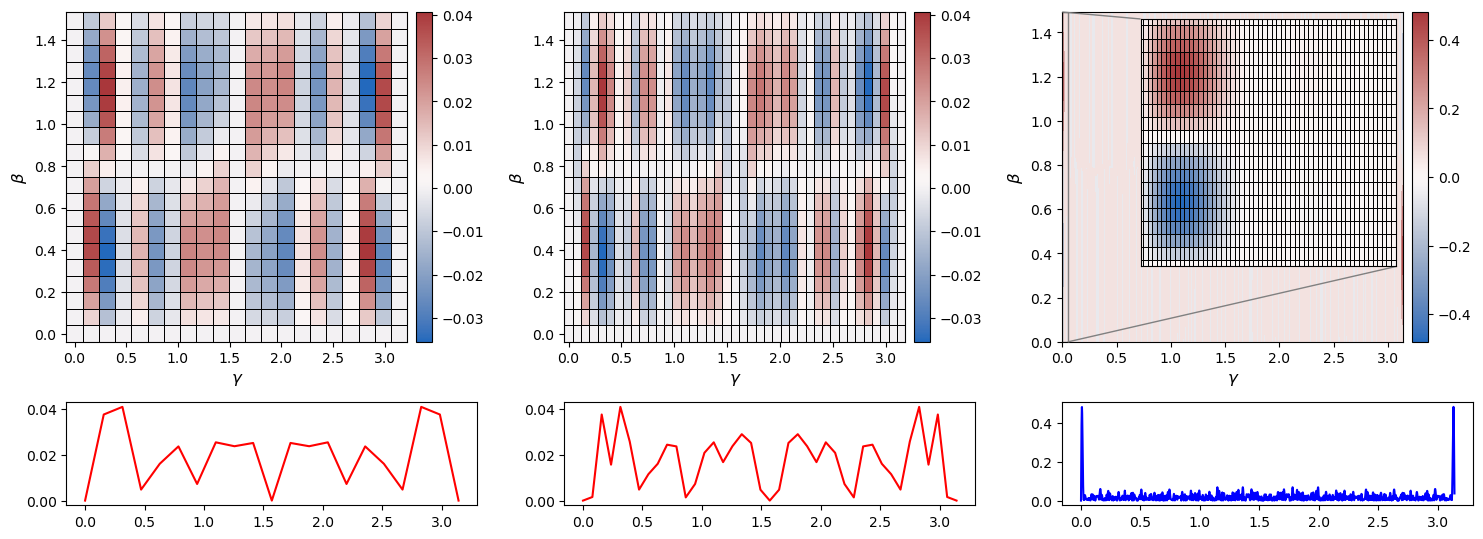

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Use a Seaborn style for clean visuals
#sns.set(style='whitegrid')

# Create a figure and a GridSpec with height ratios
fig = plt.figure(figsize=(15, 5.5))
gs = fig.add_gridspec(2, 3, height_ratios=[0.8, 0.25])  # The first row is 3 times the height of the second row

# Define common colormap
cmap = 'vlag'

# First grid plot using pcolormesh
ax1 = fig.add_subplot(gs[0, 0])
cp1 = ax1.pcolormesh(gamma1, beta1, cost_values1 / opt_cost, cmap=cmap, edgecolors='black', linewidth=0.5)
ax1.set_xlabel(r'$\gamma$', fontsize=12)
ax1.set_ylabel(r'$\beta$', fontsize=12)
fig.colorbar(cp1, ax=ax1, orientation='vertical', pad=0.02)

# Second grid plot using pcolormesh
ax2 = fig.add_subplot(gs[0, 1])
cp2 = ax2.pcolormesh(gamma2, beta2, cost_values2 / opt_cost, cmap=cmap, edgecolors='black', linewidth=0.5)
ax2.set_xlabel(r'$\gamma$', fontsize=12)
ax2.set_ylabel(r'$\beta$', fontsize=12)
fig.colorbar(cp2, ax=ax2, orientation='vertical', pad=0.02)

# Third grid plot using contourf
ax3 = fig.add_subplot(gs[0, 2])
cp3 = ax3.contourf(gamma4, beta4, cost_values4 / opt_cost, cmap=cmap)
ax3.set_xlabel(r'$\gamma$', fontsize=12)
ax3.set_ylabel(r'$\beta$', fontsize=12)

# Inset plot for the 4th plot within the 3rd plot
axins = inset_axes(ax3, width="75%", height="75%", loc='upper right')
cp4 = axins.pcolormesh(gamma4, beta4, cost_values4 / opt_cost, cmap=cmap, edgecolors='black', linewidth=0.5)
axins.set_xlim([0, 0.05])
axins.set_ylim([0, max(beta3.ravel())])  # Adjust according to the data range
axins.set_xticks([])
axins.set_yticks([])

# Draw lines connecting the inset to the main plot
mark_inset(ax3, axins, loc1=2, loc2=4, fc="none", ec="0.5")
fig.colorbar(cp4, ax=ax3, orientation='vertical', pad=0.02)

# Plotting on the second row
ax4 = fig.add_subplot(gs[1, 0])
ax4.plot(entries_list1, costs1, color='red', linewidth=1.5)

ax5 = fig.add_subplot(gs[1, 1])
ax5.plot(entries_list2, costs2, color='red', linewidth=1.5)

ax6 = fig.add_subplot(gs[1, 2])
ax6.plot(entries_list4, costs4, color='blue', linewidth=1.5)

# Adjust subplot layout for better spacing
plt.tight_layout()

# Display the plots
plt.show()


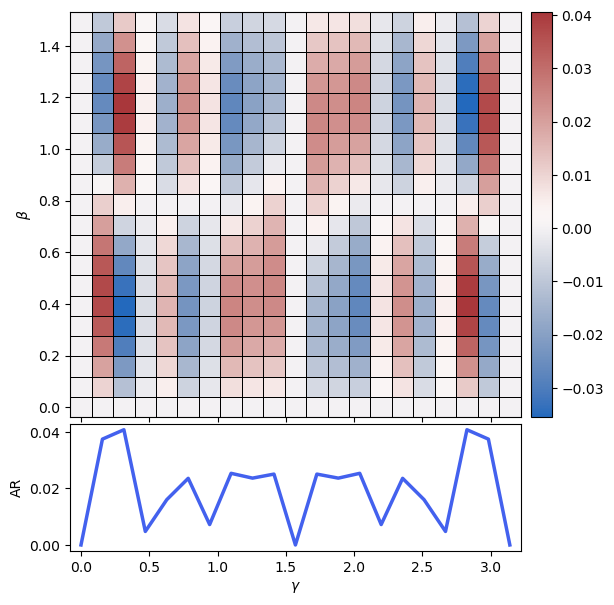

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# Use a Seaborn style for clean visuals
#sns.set(style='whitegrid')

# Create a GridSpec layout with 2 rows and 1 column, sharing the x-axis
fig = plt.figure(figsize=(7, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.8, 0.25])

# Decrease the spacing between the plots
gs.update(hspace=0.025)  # Reduce the height space between subplots

# First subplot: Contour plot with refined colors
ax2 = fig.add_subplot(gs[1, 0])
ax1 = fig.add_subplot(gs[0, 0], sharex=ax2)
cp = ax1.pcolormesh(gamma1, beta1, cost_values1 / opt_cost, cmap=cmap, edgecolors='black', linewidth=0.5)
ax1.set_ylabel(r'$\beta$')


# Remove x-axis labels from the first plot to avoid redundancy
ax1.label_outer()

# Add colorbar to the contour plot
cbar = fig.colorbar(cp, ax=ax1, orientation='vertical', pad=0.02)

# Second subplot: Line plot with the adjusted dimensions

ax2.plot(entries_list1, costs1, color='#4361ee', linewidth=2.5)
ax2.set_xlabel(r'$\gamma$')
ax2.set_ylabel('AR')

# Adjust the position of the second plot to match the width of the first plot without the color bar
pos1 = ax1.get_position()  # Get the original position of the first plot
pos2 = ax2.get_position()  # Get the original position of the second plot
ax2.set_position([pos1.x0, pos2.y0, pos1.width, pos2.height])
#ax2.set_xlim(0, entries_list1[-1])

# Fine-tune the spacing between the plots using subplots_adjust
#plt.subplots_adjust(hspace=0.1)  # Adjust spacing between subplots
plt.savefig('Conc_2Local_Plot1.pdf', bbox_inches='tight')
# Display the plots
plt.show()


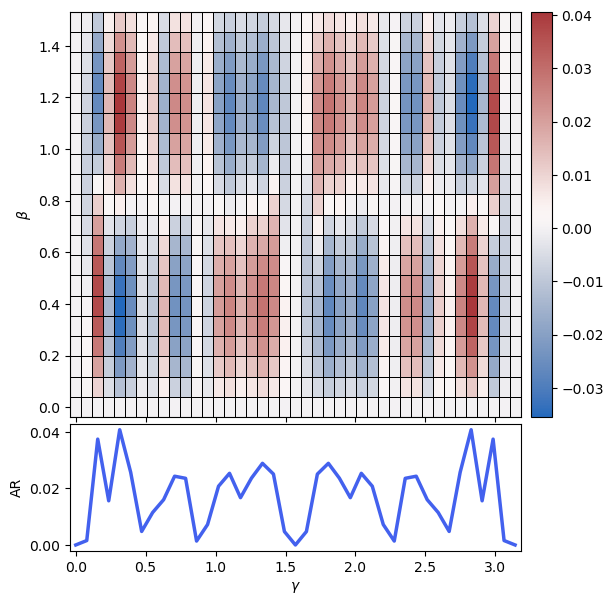

In [9]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# Use a Seaborn style for clean visuals
#sns.set(style='whitegrid')

# Create a GridSpec layout with 2 rows and 1 column, sharing the x-axis
fig = plt.figure(figsize=(7, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.8, 0.25])

# Decrease the spacing between the plots
gs.update(hspace=0.025)  # Reduce the height space between subplots

# First subplot: Contour plot with refined colors
ax2 = fig.add_subplot(gs[1, 0])
ax1 = fig.add_subplot(gs[0, 0], sharex=ax2)
cp = ax1.pcolormesh(gamma2, beta2, cost_values2 / opt_cost, cmap=cmap, edgecolors='black', linewidth=0.5)
ax1.set_ylabel(r'$\beta$')


# Remove x-axis labels from the first plot to avoid redundancy
ax1.label_outer()

# Add colorbar to the contour plot
cbar = fig.colorbar(cp, ax=ax1, orientation='vertical', pad=0.02)

# Second subplot: Line plot with the adjusted dimensions

ax2.plot(entries_list2, costs2, color='#4361ee', linewidth=2.5)
ax2.set_xlabel(r'$\gamma$')
ax2.set_ylabel('AR')

# Adjust the position of the second plot to match the width of the first plot without the color bar
pos1 = ax1.get_position()  # Get the original position of the first plot
pos2 = ax2.get_position()  # Get the original position of the second plot
ax2.set_position([pos1.x0, pos2.y0, pos1.width, pos2.height])
#ax2.set_xlim(0, entries_list1[-1])

# Fine-tune the spacing between the plots using subplots_adjust
#plt.subplots_adjust(hspace=0.1)  # Adjust spacing between subplots
plt.savefig('Conc_2Local_Plot2.pdf', bbox_inches='tight')
# Display the plots
plt.show()


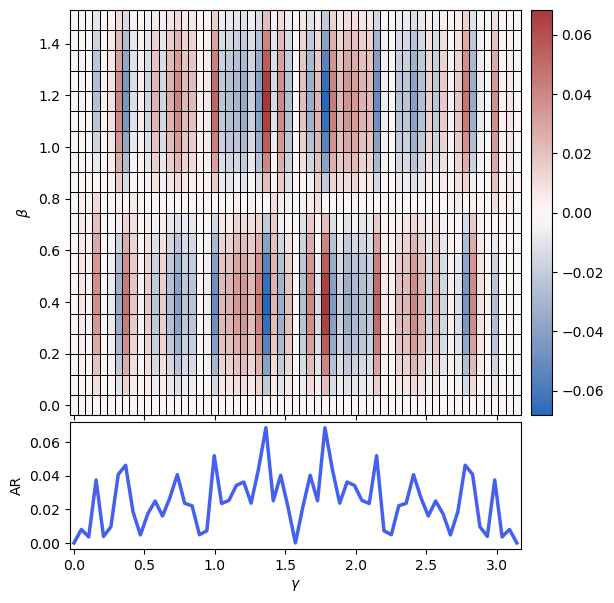

In [10]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# Use a Seaborn style for clean visuals
#sns.set(style='whitegrid')

# Create a GridSpec layout with 2 rows and 1 column, sharing the x-axis
fig = plt.figure(figsize=(7, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.8, 0.25])

# Decrease the spacing between the plots
gs.update(hspace=0.025)  # Reduce the height space between subplots

# First subplot: Contour plot with refined colors
ax2 = fig.add_subplot(gs[1, 0])
ax1 = fig.add_subplot(gs[0, 0], sharex=ax2)
cp = ax1.pcolormesh(gamma3, beta3, cost_values3 / opt_cost, cmap=cmap, edgecolors='black', linewidth=0.5)
ax1.set_ylabel(r'$\beta$')


# Remove x-axis labels from the first plot to avoid redundancy
ax1.label_outer()

# Add colorbar to the contour plot
cbar = fig.colorbar(cp, ax=ax1, orientation='vertical', pad=0.02)

# Second subplot: Line plot with the adjusted dimensions

ax2.plot(entries_list3, costs3, color='#4361ee', linewidth=2.5)
ax2.set_xlabel(r'$\gamma$')
ax2.set_ylabel('AR')

# Adjust the position of the second plot to match the width of the first plot without the color bar
pos1 = ax1.get_position()  # Get the original position of the first plot
pos2 = ax2.get_position()  # Get the original position of the second plot
ax2.set_position([pos1.x0, pos2.y0, pos1.width, pos2.height])
#ax2.set_xlim(0, entries_list1[-1])

# Fine-tune the spacing between the plots using subplots_adjust
#plt.subplots_adjust(hspace=0.1)  # Adjust spacing between subplots
plt.savefig('Conc_2Local_Plot3.pdf', bbox_inches='tight')
# Display the plots
plt.show()


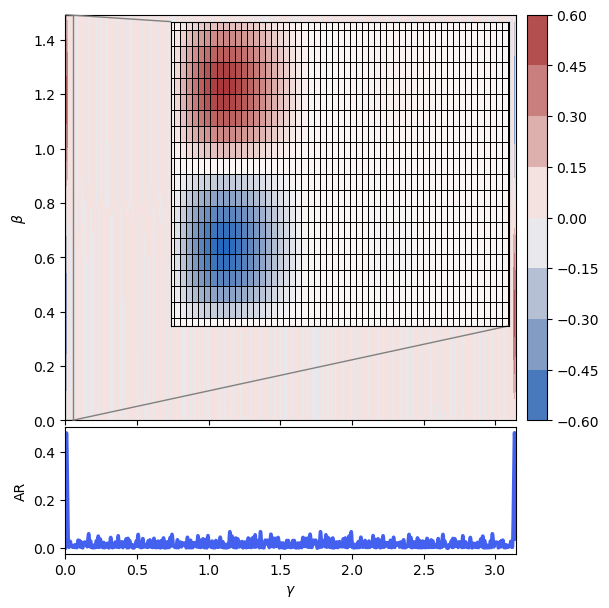

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec

# Use a Seaborn style for clean visuals
#sns.set(style='whitegrid')

# Create a GridSpec layout with 2 rows and 1 column, sharing the x-axis
fig = plt.figure(figsize=(7, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.8, 0.25])

# Decrease the spacing between the plots
gs.update(hspace=0.025)  # Reduce the height space between subplots

# First subplot: Contour plot with refined colors
ax2 = fig.add_subplot(gs[1, 0])
ax1 = fig.add_subplot(gs[0, 0], sharex=ax2)
cp = ax1.contourf(gamma4, beta4, cost_values4 / opt_cost, cmap=cmap)
ax1.set_ylabel(r'$\beta$')


# Remove x-axis labels from the first plot to avoid redundancy
ax1.label_outer()

# Add colorbar to the contour plot
cbar = fig.colorbar(cp, ax=ax1, orientation='vertical', pad=0.02)

# Inset plot for the 4th plot within the 3rd plot
axins = inset_axes(ax1, width="75%", height="75%", loc='upper right')
cp4 = axins.pcolormesh(gamma4, beta4, cost_values4 / opt_cost, cmap=cmap, edgecolors='black', linewidth=0.5)
axins.set_xlim([0, 0.05])
axins.set_ylim([0, max(beta4.ravel())])  # Adjust according to the data range
axins.set_xticks([])
axins.set_yticks([])
mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="0.5")

# Second subplot: Line plot with the adjusted dimensions

ax2.plot(entries_list4, costs4, color='#4361ee', linewidth=2.5)
ax2.set_xlabel(r'$\gamma$')
ax2.set_ylabel('AR')

# Adjust the position of the second plot to match the width of the first plot without the color bar
pos1 = ax1.get_position()  # Get the original position of the first plot
pos2 = ax2.get_position()  # Get the original position of the second plot
ax2.set_position([pos1.x0, pos2.y0, pos1.width, pos2.height])
#ax2.set_xlim(0, entries_list1[-1])

# Fine-tune the spacing between the plots using subplots_adjust
#plt.subplots_adjust(hspace=0.1)  # Adjust spacing between subplots
#plt.savefig('Conc_2Local_Plot4.pdf', bbox_inches='tight')
# Display the plots
plt.show()


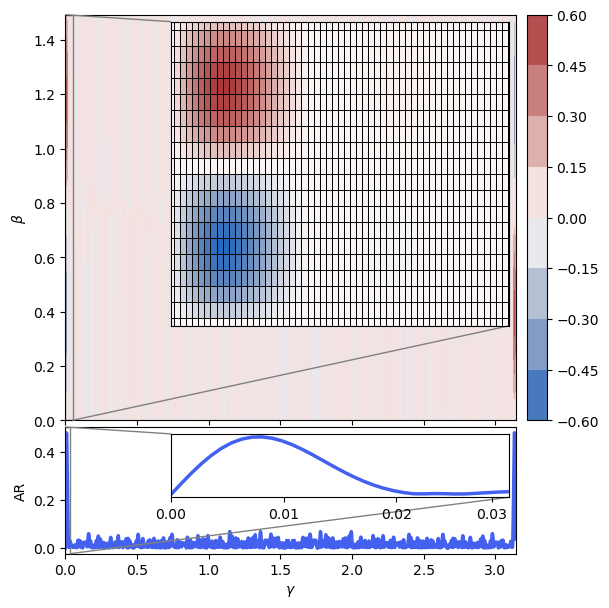

In [12]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.gridspec as gridspec
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Use a Seaborn style for clean visuals
#sns.set(style='whitegrid')

# Create a GridSpec layout with 2 rows and 1 column, sharing the x-axis
fig = plt.figure(figsize=(7, 7))
gs = gridspec.GridSpec(2, 1, height_ratios=[0.8, 0.25])

# Decrease the spacing between the plots
gs.update(hspace=0.025)  # Reduce the height space between subplots

# First subplot: Contour plot with refined colors
ax2 = fig.add_subplot(gs[1, 0])
ax1 = fig.add_subplot(gs[0, 0], sharex=ax2)
cp = ax1.contourf(gamma4, beta4, cost_values4 / opt_cost, cmap=cmap)
ax1.set_ylabel(r'$\beta$')

# Remove x-axis labels from the first plot to avoid redundancy
ax1.label_outer()

# Add colorbar to the contour plot
cbar = fig.colorbar(cp, ax=ax1, orientation='vertical', pad=0.02)

# Inset plot for the 4th plot within the 3rd plot (for contour)
axins = inset_axes(ax1, width="75%", height="75%", loc='upper right')
cp4 = axins.pcolormesh(gamma4, beta4, cost_values4 / opt_cost, cmap=cmap, edgecolors='black', linewidth=0.5)
axins.set_xlim([0, 0.05])
axins.set_ylim([0, max(beta4.ravel())])  # Adjust according to the data range
axins.set_xticks([])
axins.set_yticks([])
mark_inset(ax1, axins, loc1=2, loc2=4, fc="none", ec="0.5")

# Second subplot: Line plot with the adjusted dimensions
ax2.plot(entries_list4, costs4, color='#4361ee', linewidth=2.5)
ax2.set_xlabel(r'$\gamma$')
ax2.set_ylabel('AR')

# Inset plot for ax2, zooming into the region very close to gamma = 0
axins2 = inset_axes(ax2, width="75%", height="50%", loc='upper right')
axins2.plot(entries_list4, costs4, color='#4361ee', linewidth=2.5)
axins2.set_xlim([0, 0.03])  # Zoom into gamma near 0

# Setting the x-ticks and modifying the last x-tick to offset it
axins2.set_xticks([0, 0.01, 0.02, 0.0285])
axins2.set_xticklabels(['0.00', '0.01', '0.02', '0.03'])  # Offset the last xtick label slightly

axins2.set_yticks([])  # Optionally, you can remove y-ticks for the inset
mark_inset(ax2, axins2, loc1=2, loc2=4, fc="none", ec="0.5")

# Adjust the position of the second plot to match the width of the first plot without the color bar
pos1 = ax1.get_position()  # Get the original position of the first plot
pos2 = ax2.get_position()  # Get the original position of the second plot
ax2.set_position([pos1.x0, pos2.y0, pos1.width, pos2.height])

# Save the figure
plt.savefig('Conc_2Local_Plot4.pdf', bbox_inches='tight')

# Display the plots
plt.show()
